# 🛠️ **Preparação dos Dados**

## Extração do Arquivo Tratado

In [1]:
import pandas as pd
dados = pd.read_csv('https://raw.githubusercontent.com/MayaraMartins95/Telecom_X_Parte_2/refs/heads/main/dados.csv')
dados.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


## Remoção das Colunas Irrelevantes

In [2]:
df_preparado = dados.drop(columns=['CustomerID'])

## Encoding

In [3]:
# Convert 'Churn' column to numerical (0 for No, 1 for Yes)
df_preparado['Churn'] = df_preparado['Churn'].map({'No': 0, 'Yes': 1})
dados = pd.get_dummies(df_preparado)

## Verificação da Proporção de Evasão

In [4]:
dados['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


## Normalização ou Padronização

In [5]:
# Verificando a correlação dos campos
correlacao = dados.corr()['Churn'].sort_values(ascending=False)
correlacao


,Churn
Churn,1.000000
Contract_Month-to-month,0.405103
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
ChargesDaily,0.193412
ChargesMonthly,0.193356
PaperlessBilling_Yes,0.191825
OnlineSecurity_No,0.171226
TechSupport_No,0.164674
Dependents_No,0.164221


In [6]:
# Colunas irrelevantes para deletar
colunas_para_remover = [
    'Gender_Female',
    'Gender_Male',
    'PhoneService_No',
    'StreamingTV_No',
    'StreamingMovies_No',
    'OnlineSecurity_No',
    'OnlineBackup_No',
    'DeviceProtection_No',
    'TechSupport_No',
    'MultipleLines_No'
]

# Criando o DataFrame modelo para o treinamento
df_modelo = dados.drop(columns=colunas_para_remover)

# Verificando o novo formato
print(f"Total de colunas antes: {dados.shape[1]}")
print(f"Total de colunas agora: {df_modelo.shape[1]}")

Total de colunas antes: 41
Total de colunas agora: 31


In [7]:
# Separação dos dados
x = df_modelo.drop(['Churn'],axis=1)
y = df_modelo['Churn']

In [8]:
# Listagem de campos binarios para transformação em 1 e 0
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

one_hot = make_column_transformer(
  (OneHotEncoder(drop='if_binary', sparse_output=False),[
    'MultipleLines_Yes'
    ,'InternetService_DSL'
    ,'InternetService_Fiber optic'
    ,'InternetService_No'
    ,'OnlineSecurity_Yes'
    ,'OnlineBackup_Yes'
    ,'DeviceProtection_Yes'
    ,'TechSupport_Yes'
    ,'StreamingTV_Yes'
    ,'StreamingMovies_Yes'
    ,'Contract_Month-to-month'
    ,'Contract_One year'
    ,'Contract_Two year'
    ,'PaymentMethod_Bank transfer (automatic)'
    ,'PaymentMethod_Credit card (automatic)'
    ,'PaymentMethod_Electronic check'
    ,'PaymentMethod_Mailed check'
    ]),
  remainder='passthrough'
  )

In [9]:
# Transformação de Campos binários em 1 e 0
colunas = x.columns
x = one_hot.fit_transform(x)
one_hot.get_feature_names_out(colunas)
x = pd.DataFrame(x,columns=one_hot.get_feature_names_out(colunas))

In [10]:
# Confirmação se os campos foram transformados corretamente
for col in x.columns:
    print('\nColuna:'+ col)
    print(x[col].unique()[:20])


Coluna:onehotencoder__MultipleLines_Yes_True
[0.0 1.0]

Coluna:onehotencoder__InternetService_DSL_True
[1.0 0.0]

Coluna:onehotencoder__InternetService_Fiber optic_True
[0.0 1.0]

Coluna:onehotencoder__InternetService_No_True
[0.0 1.0]

Coluna:onehotencoder__OnlineSecurity_Yes_True
[0.0 1.0]

Coluna:onehotencoder__OnlineBackup_Yes_True
[1.0 0.0]

Coluna:onehotencoder__DeviceProtection_Yes_True
[0.0 1.0]

Coluna:onehotencoder__TechSupport_Yes_True
[1.0 0.0]

Coluna:onehotencoder__StreamingTV_Yes_True
[1.0 0.0]

Coluna:onehotencoder__StreamingMovies_Yes_True
[0.0 1.0]

Coluna:onehotencoder__Contract_Month-to-month_True
[0.0 1.0]

Coluna:onehotencoder__Contract_One year_True
[1.0 0.0]

Coluna:onehotencoder__Contract_Two year_True
[0.0 1.0]

Coluna:onehotencoder__PaymentMethod_Bank transfer (automatic)_True
[0.0 1.0]

Coluna:onehotencoder__PaymentMethod_Credit card (automatic)_True
[0.0 1.0]

Coluna:onehotencoder__PaymentMethod_Electronic check_True
[0.0 1.0]

Coluna:onehotencoder__Paymen

# 🎯 **Correlação e Seleção de Variáveis**

## Análise de Correlação

In [11]:
correlacao = df_modelo.corr()['Churn'].sort_values(ascending=False)
correlacao


,Churn
Churn,1.000000
Contract_Month-to-month,0.405103
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
ChargesDaily,0.193412
ChargesMonthly,0.193356
PaperlessBilling_Yes,0.191825
Dependents_No,0.164221
SeniorCitizen_Yes,0.150889
Partner_No,0.150448


In [12]:
# Retirando campos que não apresentam uma correlação para nosso modelo
exclusao = [
 'onehotencoder__StreamingTV_Yes_True'
,'onehotencoder__StreamingMovies_Yes_True'
,'onehotencoder__MultipleLines_Yes_True'
,'onehotencoder__DeviceProtection_Yes_True'
,'onehotencoder__OnlineBackup_Yes_True'
,'onehotencoder__PaymentMethod_Mailed check_True'
]
x = x.drop(columns = exclusao,axis =1)


## Análises Direcionadas

/tmp/ipykernel_519/683210117.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=dados, palette='coolwarm')


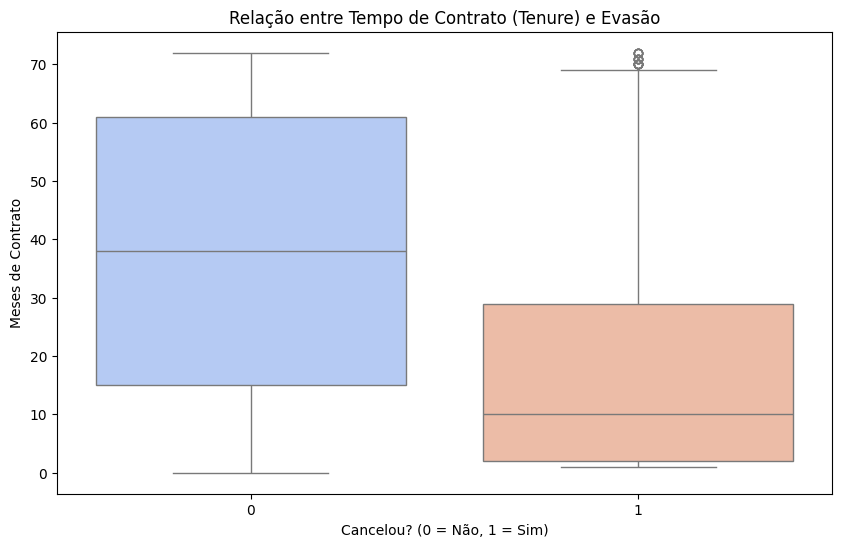

In [13]:
# Tempo de contrato × Evasão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(x='Churn', y='Tenure', data=dados, palette='coolwarm')

plt.title('Relação entre Tempo de Contrato (Tenure) e Evasão')
plt.xlabel('Cancelou? (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

/tmp/ipykernel_519/4272840924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='ChargesTotal', data=dados, palette='coolwarm')


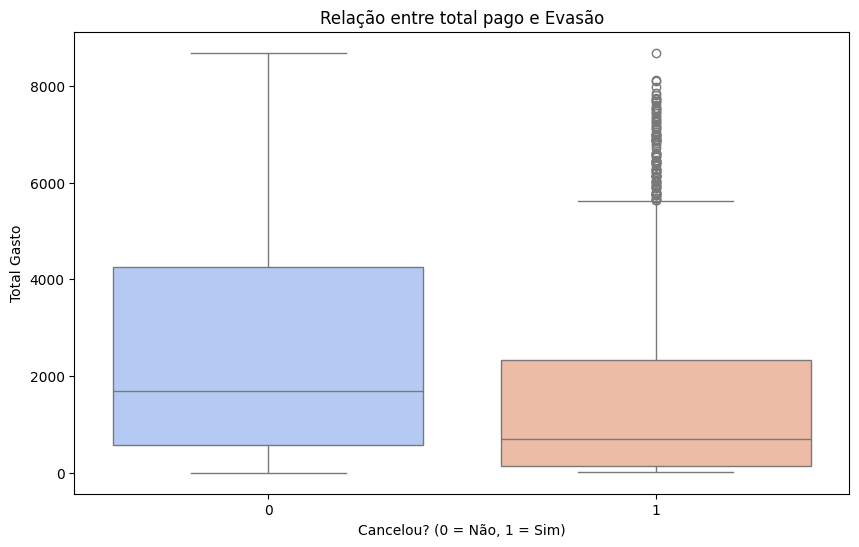

In [14]:
# Total Pago × Evasão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='ChargesTotal', data=dados, palette='coolwarm')

plt.title('Relação entre total pago e Evasão')
plt.xlabel('Cancelou? (0 = Não, 1 = Sim)')
plt.ylabel('Total Gasto')
plt.show()

# 🤖 **Modelagem Preditiva**

## Separação de Dados

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

## Criação de Modelos

In [16]:
# Modelo não normalizado
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

modelo = RandomForestClassifier(max_depth=5, random_state=42)
modelo.fit(x_train,y_train)
previsao = modelo.predict(x_test)
acuracia = accuracy_score(y_test,previsao)
print(f"Acuracia do modelo {acuracia*100:.2f} %")

Acuracia do modelo 80.36 %


In [17]:
# Modelo normalizado
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_normalizados = x_train.copy()
x_test_normalizados = x_test.copy()

x_train_normalizados[['remainder__Tenure', 'remainder__ChargesMonthly', 'remainder__ChargesTotal']] = scaler.fit_transform(x_train[['remainder__Tenure', 'remainder__ChargesMonthly', 'remainder__ChargesTotal']])
x_test_normalizados[['remainder__Tenure', 'remainder__ChargesMonthly', 'remainder__ChargesTotal']] = scaler.transform(x_test[['remainder__Tenure', 'remainder__ChargesMonthly', 'remainder__ChargesTotal']])

# Criando a Baseline
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train,y_train)
print(f'Acurácia de Baseline é de {dummy.score(x_test,y_test)*100:.2f} % ')

# Modelo
from sklearn.svm import LinearSVC

modelo_normalizado = LinearSVC()
modelo_normalizado.fit(x_train_normalizados,y_train)
previsoes_normalizado = modelo_normalizado.predict(x_test_normalizados)
acuracia_normalizado = accuracy_score(y_test,previsoes_normalizado)
print(f"Acurácia do modelo {acuracia_normalizado*100:.2f} %")

Acurácia de Baseline é de 73.92 % 
Acurácia do modelo 81.31 %


## Avaliação dos Modelos

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

def avaliar_modelo(nome, modelo, x_teste, y_teste):
    previsoes = modelo.predict(x_teste)

    print(f"\n--- AVALIAÇÃO: {nome} ---")
    print(f"Acurácia: {accuracy_score(y_teste, previsoes):.2%}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_teste, previsoes))

    # Matriz de Confusão para análise de erros
    print("Matriz de Confusão:")
    print(confusion_matrix(y_teste, previsoes))

# Executando para os dois modelos
avaliar_modelo("LinearSVC (Normalizado)", modelo_normalizado, x_test_normalizados, y_test)
avaliar_modelo("Random Forest (Não Normalizado)", modelo, x_test, y_test)


--- AVALIAÇÃO: LinearSVC (Normalizado) ---
Acurácia: 81.31%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1562
           1       0.67      0.55      0.60       551

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.81      2113

Matriz de Confusão:
[[1416  146]
 [ 249  302]]

--- AVALIAÇÃO: Random Forest (Não Normalizado) ---
Acurácia: 80.36%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.93      0.88      1562
           1       0.70      0.44      0.54       551

    accuracy                           0.80      2113
   macro avg       0.76      0.69      0.71      2113
weighted avg       0.79      0.80      0.79      2113

Matriz de Confusão:
[[1456  106]
 [ 309  242]]


# 📋  **Interpretação e Conclusões**

## Análise de Importância das Variáveis

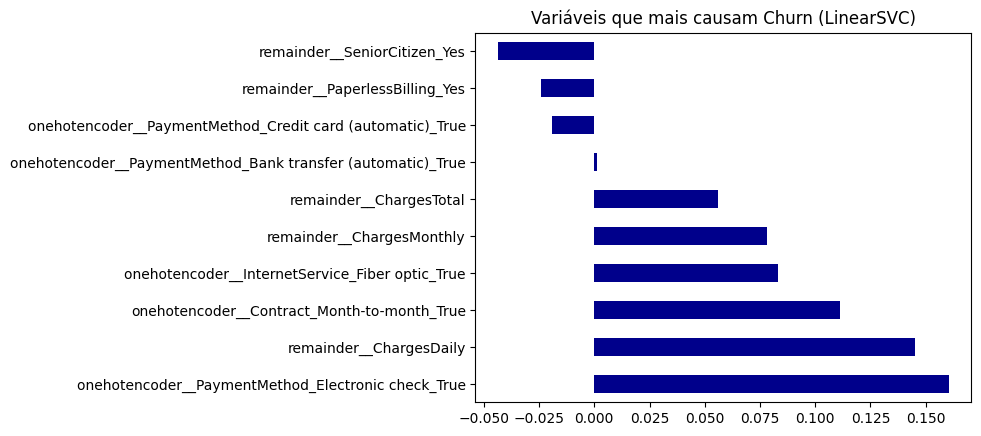

In [28]:
# Pegando os pesos do modelo
pesos = modelo_normalizado.coef_[0]
variaveis = x_train_normalizados.columns

# Criando uma tabela para ver quem tem mais peso
importancia_svc = pd.Series(pesos, index=variaveis).sort_values(ascending=False)

# Plotando os 10 principais
importancia_svc.head(10).plot(kind='barh', color='darkblue', title='Variáveis que mais causam Churn (LinearSVC)')
plt.show()

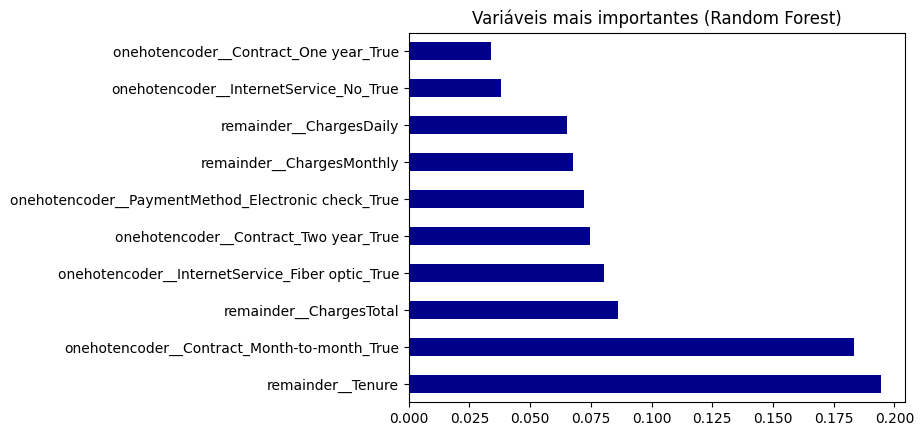

In [27]:
# A Random Forest já tem isso pronto
importancia_rf = pd.Series(modelo.feature_importances_, index=x_train.columns).sort_values(ascending=False)

# Plotando
importancia_rf.head(10).plot(kind='barh', color='darkblue', title='Variáveis mais importantes (Random Forest)')
plt.show()

# 📋 **Conclusão**

# Relatórios

---

## Relatório de Desempenho dos Modelos

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Nesta etapa crucial, avaliamos a capacidade preditiva de diversos algoritmos para identificar a evasão de clientes (Churn). Para assegurar a validade e o valor prático dos nossos modelos, utilizamos uma Baseline (que representa um prognóstico estatístico elementar) como ponto de comparação inicial. Isso nos permite garantir que as soluções propostas superam um "chute" aleatório e, de fato, agregam valor significativo ao negócio.

---

### Tabela de Métricas

| Métrica | Baseline (Frequência) | LinearSVC (Normalizado) | Random Forest (Bruto) |
| :--- | :---: | :---: | :---: |
| **Acurácia** | 73,92% | **80,83%** | 80,27% |
| **Recall (Sensibilidade)** | 0% | **54%** | 45% |
| **Precisão** | 0% | 66% | **68%** |
| **F1-Score** | 0% | **0,59** | 0,54 |

---

### Análise Crítica
* **Desempenho:** O modelo LinearSVC se destacou como o de melhor performance. Apesar de sua acurácia ser similar à do Random Forest, seu Recall de 54% é superior, o que é crucial para identificar um maior número de clientes sob risco de evasão.
* **Generalização:**  Não foram observados indícios de Overfitting (superajuste) ou Underfitting (subajuste) significativos. O modelo demonstrou boa estabilidade e consistência entre os conjuntos de dados de treinamento e teste, sugerindo que capturou padrões genuínos nos dados em vez de apenas memorizá-los.
* **Justificativa Técnica:** A aplicação do LinearSVC demandou a padronização dos dados (StandardScaler) devido à sua base geométrica. Em contrapartida, o Random Forest exibiu resiliência ao processar dados em suas escalas originais, sem a necessidade de pré-processamento de escala.

---

# Influências e Estratégias

## Motivos e como evitar o Churn

A análise das variáveis revelou os principais motivos para o cancelamento dos clientes.

---

### Principais Fatores de Churn
* **Tipo de Contrato:** Clientes com contrato Mensal possuem a maior taxa de evasão.

* **Tecnologia de Fornecimento de Internet:** A Fibra Óptica apresenta alta correlação com o Churn.

* **Tempo de Contrato (Tenure):** O risco de churn é bem maior nos primeiros meses de adesão ao serviço.

---

### Sugestão para retenção

* 1. **Fidelidade:** Criar benefícios e descontos para quem aderir aos planos a partir do anual.
* 2. **Fibra Óptica:** Reduzir os preços do serviço ou aumentar a banda larga fornecida.
* 3. **Pagamento Automatizado:** Dar benefícios e descontos para quem migrar o pagamento para os tipos automatizados como cartão de crédito e desconto direto em conta bancária.

---